# Noise and signal correlation in simultaneously recorded selective pairs

Every pair here is **two FDR-selective units recorded simultaneously in the same
region**. Two things are measured on those same pairs.

| | signal correlation | noise correlation |
|---|---|---|
| computed on | condition-averaged rate timelines | per-fixation 1 ms spike trains |
| asks | do their **mean responses** share a shape | do they fire together on the **same** fixation |
| null | unit of the same region, different session | circular shift within fixation |

Averaging over fixations removes trial-by-trial covariation entirely. That is
the only difference between the two paths in the schematic, and it is why a pair
can have either without the other.

Signal correlation comes first because it carries the clearer result.

In [1]:
from __future__ import annotations

from pathlib import Path
import sys

import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

repo_root = Path.cwd()
if not (repo_root / "src").exists():
    repo_root = next(parent for parent in Path.cwd().parents if (parent / "src").exists())
if str(repo_root / "src") not in sys.path:
    sys.path.insert(0, str(repo_root / "src"))

from dal_monte_2022_analysis.config.load import load_config
from dal_monte_2022_analysis.runtime.io.analysis_index import build_analysis_output_dir
from dal_monte_2022_analysis.ephys.analysis import fixation_pair_spike_coordination as psc
from dal_monte_2022_analysis.ephys.analysis import fixation_signal_correlation as sc
from dal_monte_2022_analysis.ephys.plotting import fixation_pair_correlation_overview as viz

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 50)

CFG_PATH = str(repo_root / "configs" / "dataset.yaml")
cfg = load_config(CFG_PATH)
FIGURE_DIR = build_analysis_output_dir(cfg, psc.DEFAULT_OUTPUT_SUBDIR) / "overview"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
figs = viz.PairOverviewPlotSettings(output_dir=FIGURE_DIR)
SUMMARY_DIR = build_analysis_output_dir(cfg, psc.DEFAULT_OUTPUT_SUBDIR) / "summary"
print("figures ->", FIGURE_DIR)

figures -> /gpfs/milgram/pi/chang/pg496/repositories/local_data/dal_monte_2022/analysis_outputs/ephys/psth/fixation_pair_spike_coordination/overview


/gpfs/milgram/pi/chang/pg496/repositories/dal_monte_2022_analysis/src/dal_monte_2022_analysis/ephys/plotting/fixation_pair_correlation_overview.py:182: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=(0, 0.13, 1, 0.87))


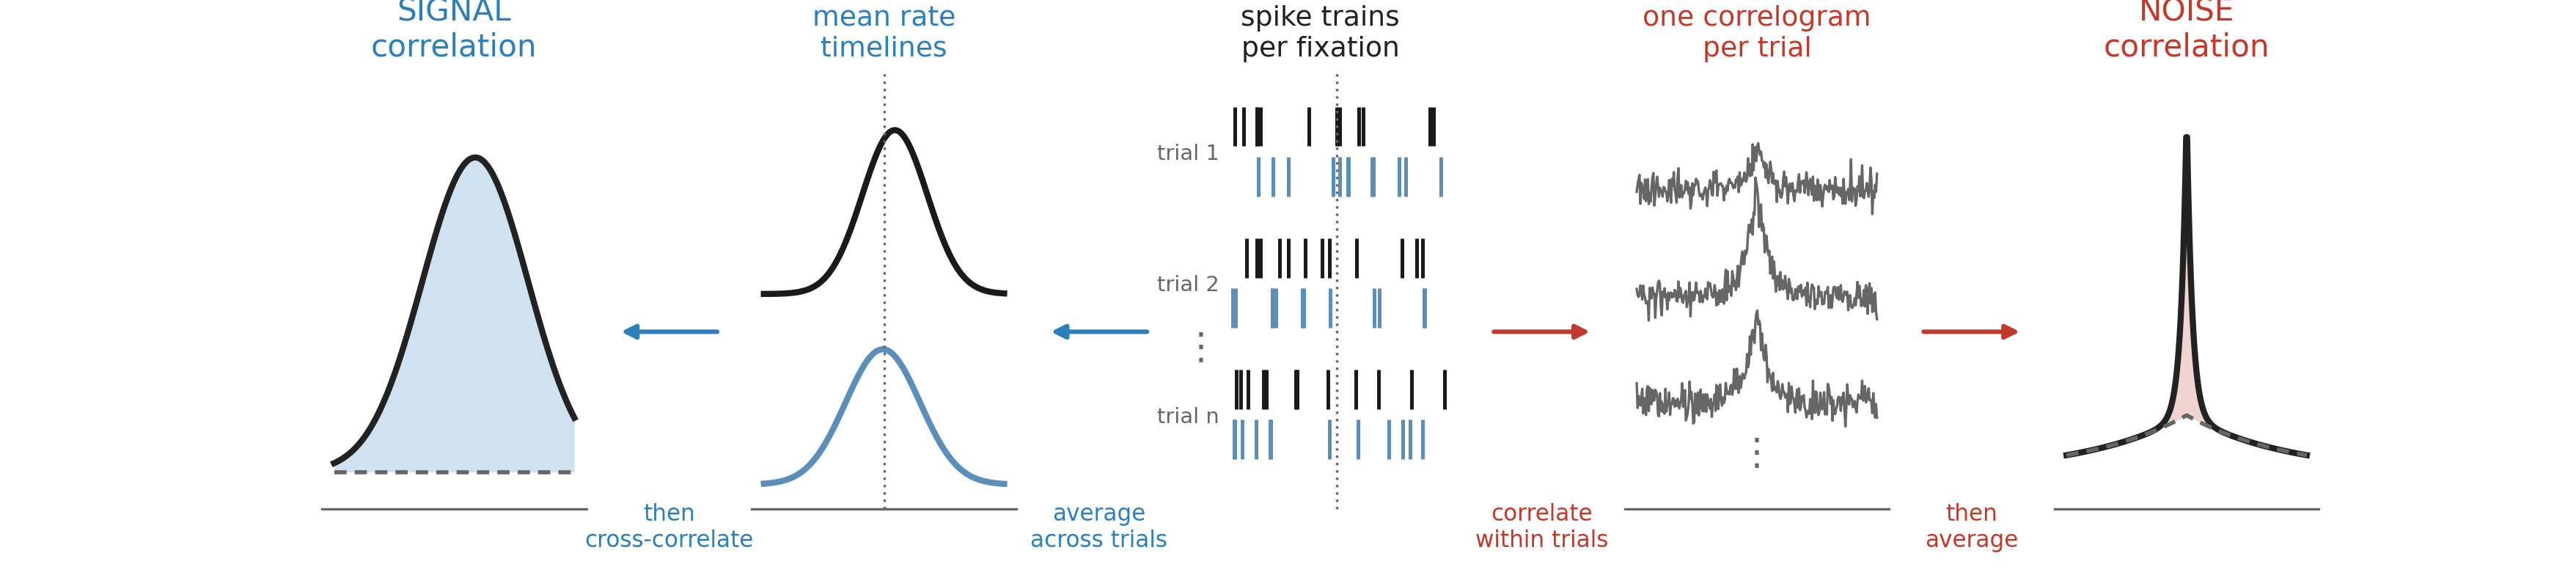

In [2]:
fig, paths = viz.plot_method_schematic(figs)
display(Image(filename=str(paths["png"])))

## 1. What is in the analysis

In [3]:
# --- noise correlation: per-fixation spike trains, circular-shift null -------
noise = psc.load_pair_coordination(CFG_PATH)[0]
noise, dropped = psc.drop_zero_lag_artifact_dates(noise)
noise = noise.loc[noise["both_selective"] & noise["same_region"]].copy()
noise_traces = pd.read_pickle(SUMMARY_DIR / "traces_by_region_selective.pkl")
print(f"noise: {len(noise):,} pair-conditions, both units FDR-selective, "
      f"within region   (artifact dates removed: {dropped})")

# --- signal correlation: condition-averaged timelines, cross-session null ----
signal_settings = sc.SignalCorrelationSettings(cfg_path=CFG_PATH)
units, timeline = sc.load_condition_timelines(signal_settings)
signal, signal_lags = sc.build_pair_correlations(units, timeline, signal_settings)
signal_within = signal.loc[signal["scope"] == "within_region"]
print(f"signal: {len(signal_within):,} within-region pairs from {len(units)} selective units")

display(
    noise.groupby("region_pair", observed=True)
    .agg(noise_pairs=("pair_key", "size"))
    .join(
        signal_within.groupby("region_pair", observed=True)
        .size().rename("signal_pairs").to_frame()
    )
)

noise: 66,864 pair-conditions, both units FDR-selective, within region   (artifact dates removed: ['09272018', '09292018'])


signal: 3,005 within-region pairs from 574 selective units


,noise_pairs,signal_pairs
region_pair,,
accg,6949,356
bla,39015,1786
dmpfc,7054,320
ofc,13846,543


# Signal correlation

## 2. Null-corrected correlation across lags

The cross-session null is subtracted, so zero means "resembles a same-region
unit from another session no more than chance".

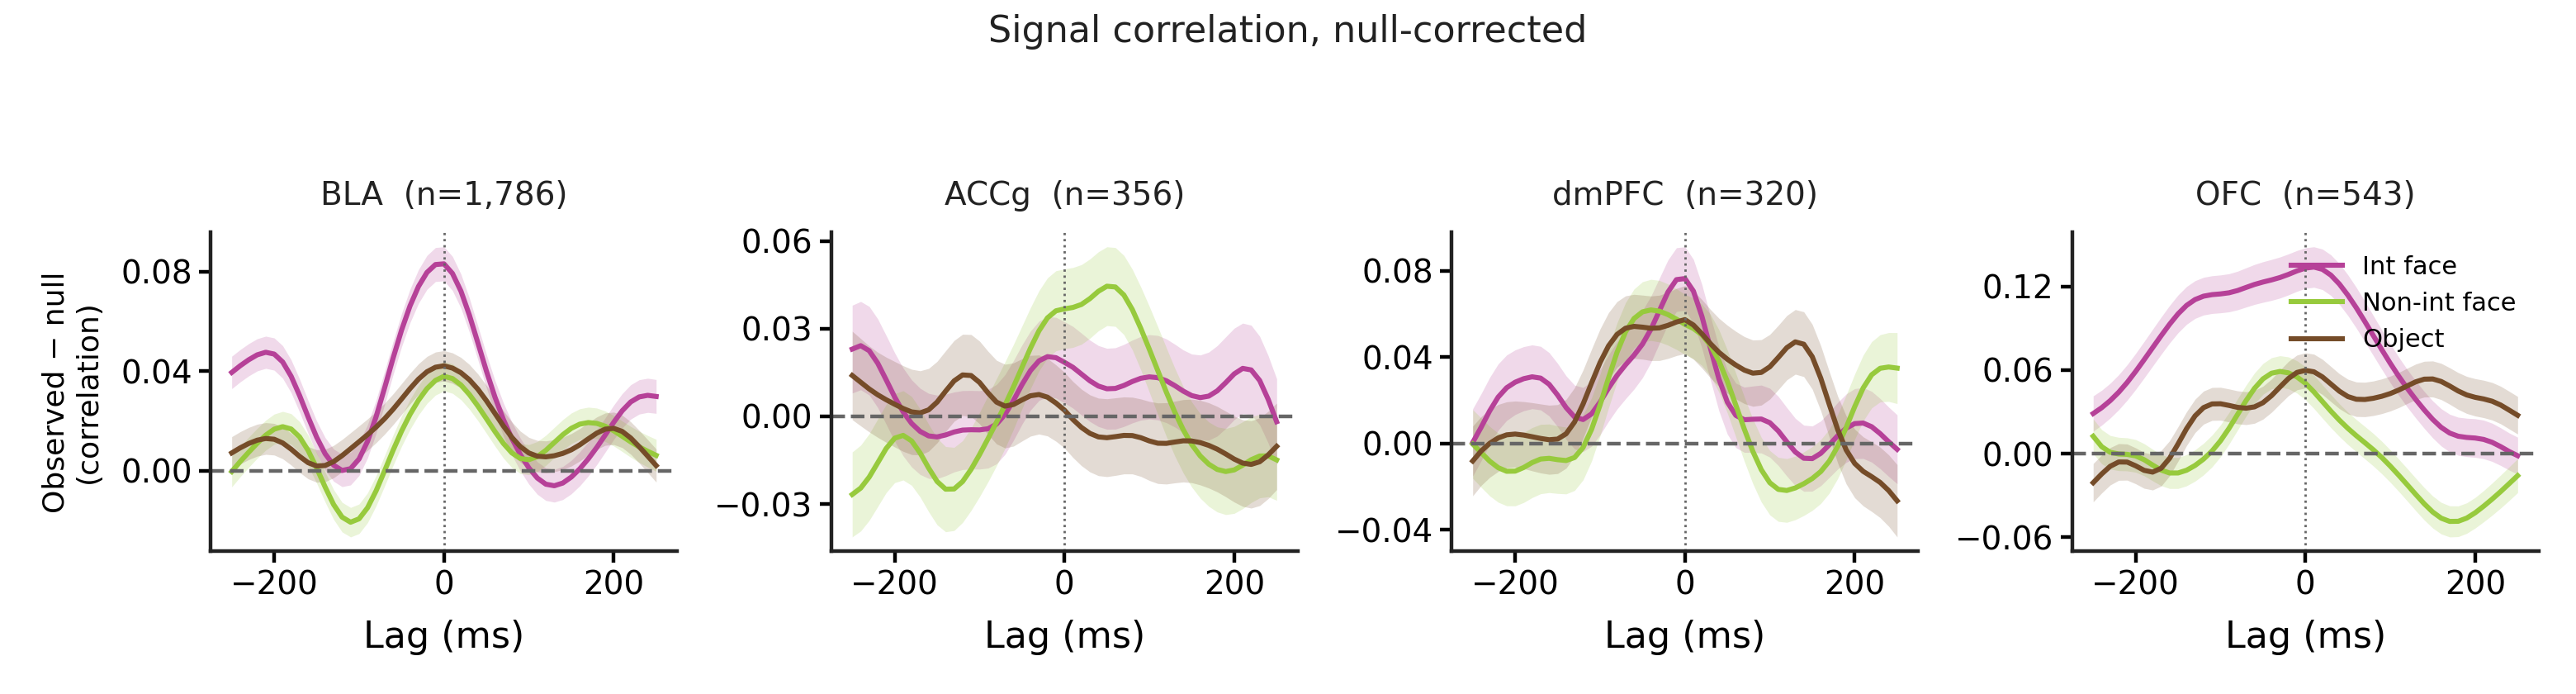

In [4]:
signal_traces = {
    "lags_ms": signal_lags,
    "traces": sc.build_group_traces(signal, signal_settings),
}
fig, paths = viz.plot_excess_by_condition(
    signal_traces, figs, max_lag_ms=250.0,
    ylabel="Observed − null\n(correlation)",
    title="Signal correlation, null-corrected",
    stem="fig04_signal_excess",
)
display(Image(filename=str(paths["png"])))

## 3. Correlation by region and fixation type

Summarised as the **mean over ±100 ms**, not at zero lag and not at the peak.

- *Not zero lag*: it is one bin of fifty, and two units whose responses share a
  shape but differ in latency correlate strongly off zero and weakly at it.
- *Not the peak*: each pair's maximum falls at a different lag, so averaging
  per-pair maxima gives a far larger number than the maximum of the average —
  a bar chart of peaks reads around 0.3 while the trace above it peaks near
  0.1. The windowed mean has no maximum in it, so the bars and the traces are
  the same quantity: the mean over pairs of this **equals** the mean of the
  group trace over the same window.

Brackets appear only where a contrast survives FDR correction. Annotating the
rest would fill the panel with numbers that all say "no difference", and the
reader would have to check each one to learn that.

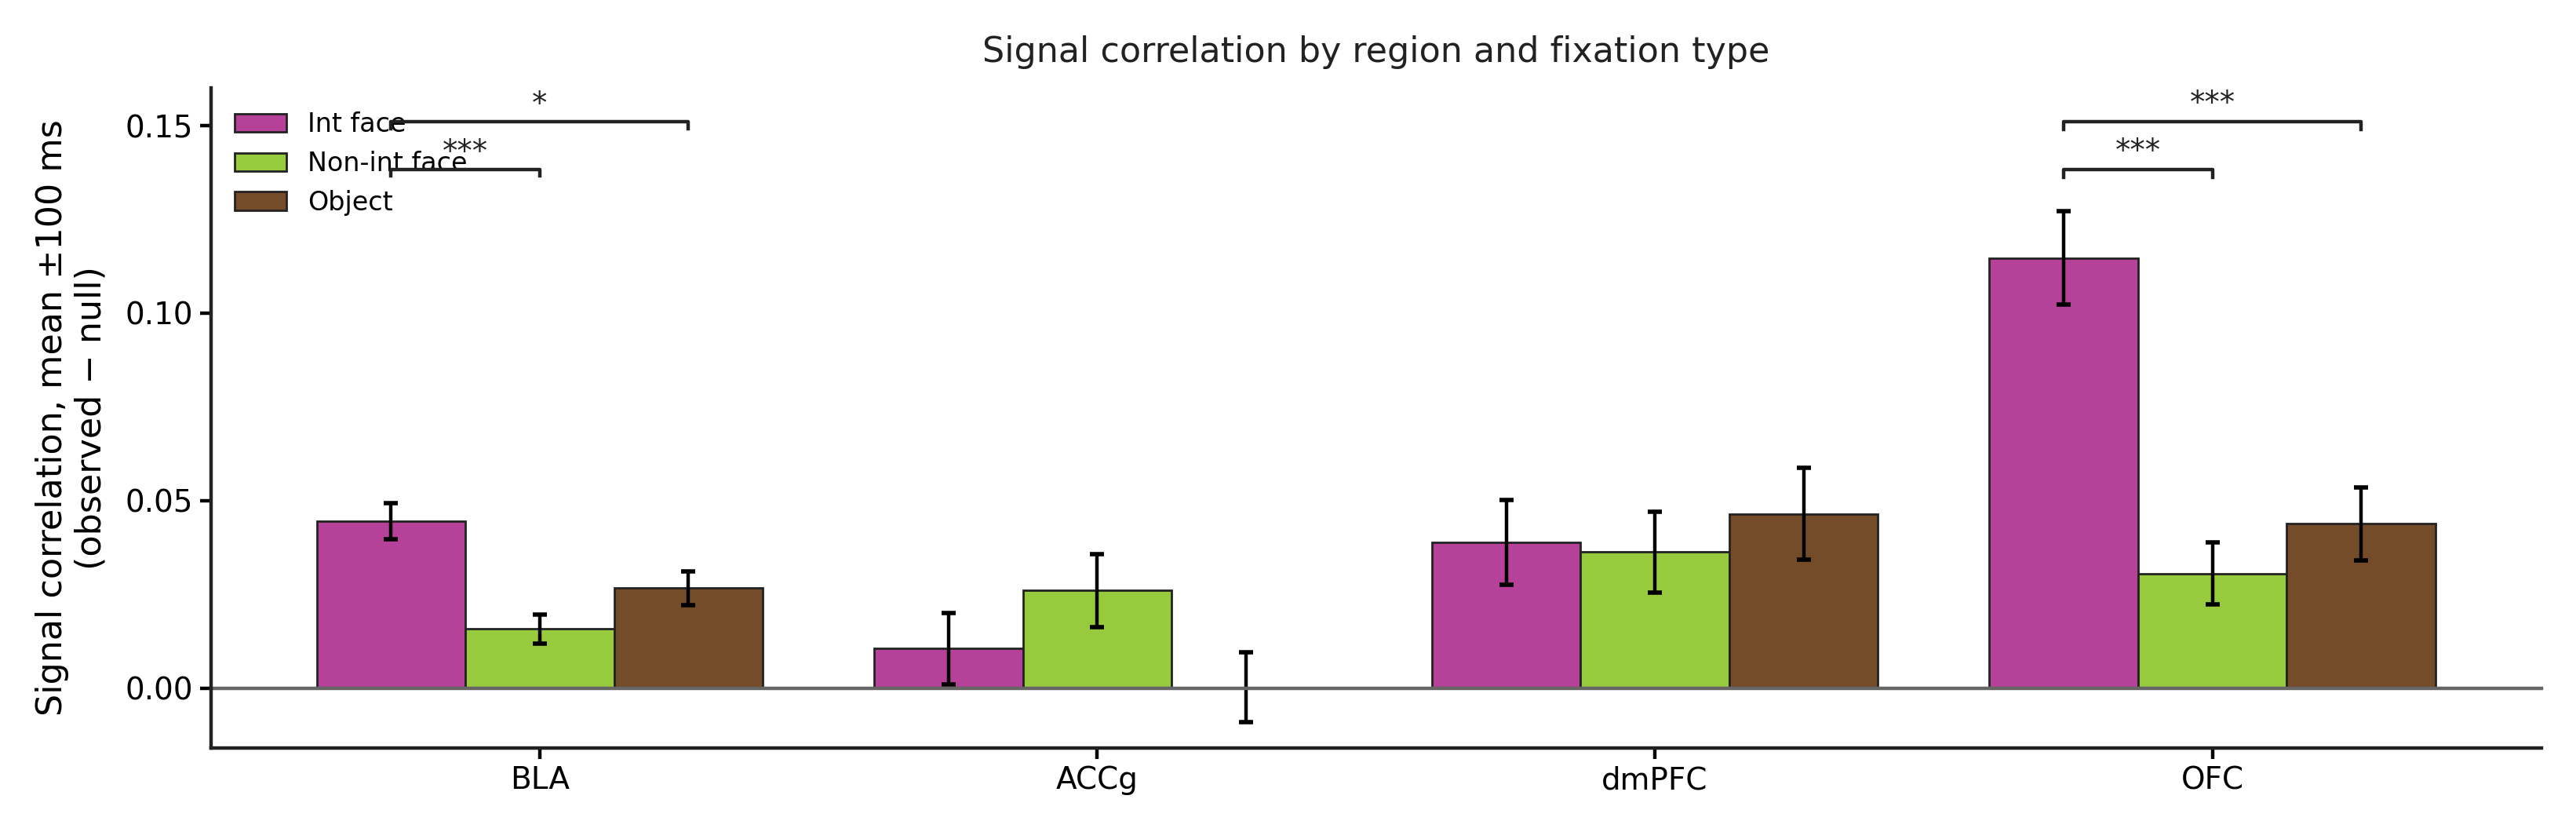

condition,face_interactive,face_non_interactive,object
region_pair,,,
accg,0.0105,0.0260,0.0002
bla,0.0445,0.0158,0.0267
dmpfc,0.0389,0.0364,0.0464
ofc,0.1147,0.0306,0.0438


,region_pair,condition_a,condition_b,n_pairs,mean_difference,effect_size_rank_biserial,p_value_corrected,significant
0,accg,face_interactive,face_non_interactive,356,-0.0155,0.0000,0.3564,False
1,accg,face_interactive,object,356,0.0103,0.0506,0.5853,False
2,accg,face_non_interactive,object,356,0.0258,0.1124,0.0888,False
3,bla,face_interactive,face_non_interactive,1786,0.0287,0.0907,0.0000,True
4,bla,face_interactive,object,1786,0.0178,0.0504,0.0111,True
5,bla,face_non_interactive,object,1786,-0.0109,-0.0291,0.2308,False
6,dmpfc,face_interactive,face_non_interactive,320,0.0025,-0.0312,0.8619,False
7,dmpfc,face_interactive,object,320,-0.0076,0.0000,0.8055,False
8,dmpfc,face_non_interactive,object,320,-0.0101,0.0250,0.9092,False
9,ofc,face_interactive,face_non_interactive,543,0.0842,0.2523,0.0000,True


In [5]:
lag_summary = sc.summarize_lag_measures(
    signal, signal_settings, measures=(sc.WINDOW_METRIC,)
)
peak_contrasts = sc.compare_lag_measures(
    signal, signal_settings, measures=(sc.WINDOW_METRIC,)
)

fig, paths = viz.plot_peak_comparison(
    lag_summary, figs, contrasts=peak_contrasts,
    title="Signal correlation by region and fixation type",
)
display(Image(filename=str(paths["png"])))

display(
    lag_summary.pivot_table(index="region_pair", columns="condition", values="mean").round(4)
)
display(
    peak_contrasts.loc[
        :, ["region_pair", "condition_a", "condition_b", "n_pairs", "mean_difference",
            "effect_size_rank_biserial", "p_value_corrected", "significant"]
    ].round(4)
)

# Noise correlation

## 4. It sits above the null in every region and condition

Rows are fixation conditions, columns are regions. The gap between the two
curves is the coordination.

The y-axis is **coincidences per fixation**, not a correlation coefficient: at
each 1 ms lag it counts spike pairs separated by that lag. Chance is roughly
`rate₁ × rate₂ × bin width`, about 0.05 for two 7 Hz units, which is why the
values sit where they do — and why they are not comparable in magnitude with the
signal correlation above.

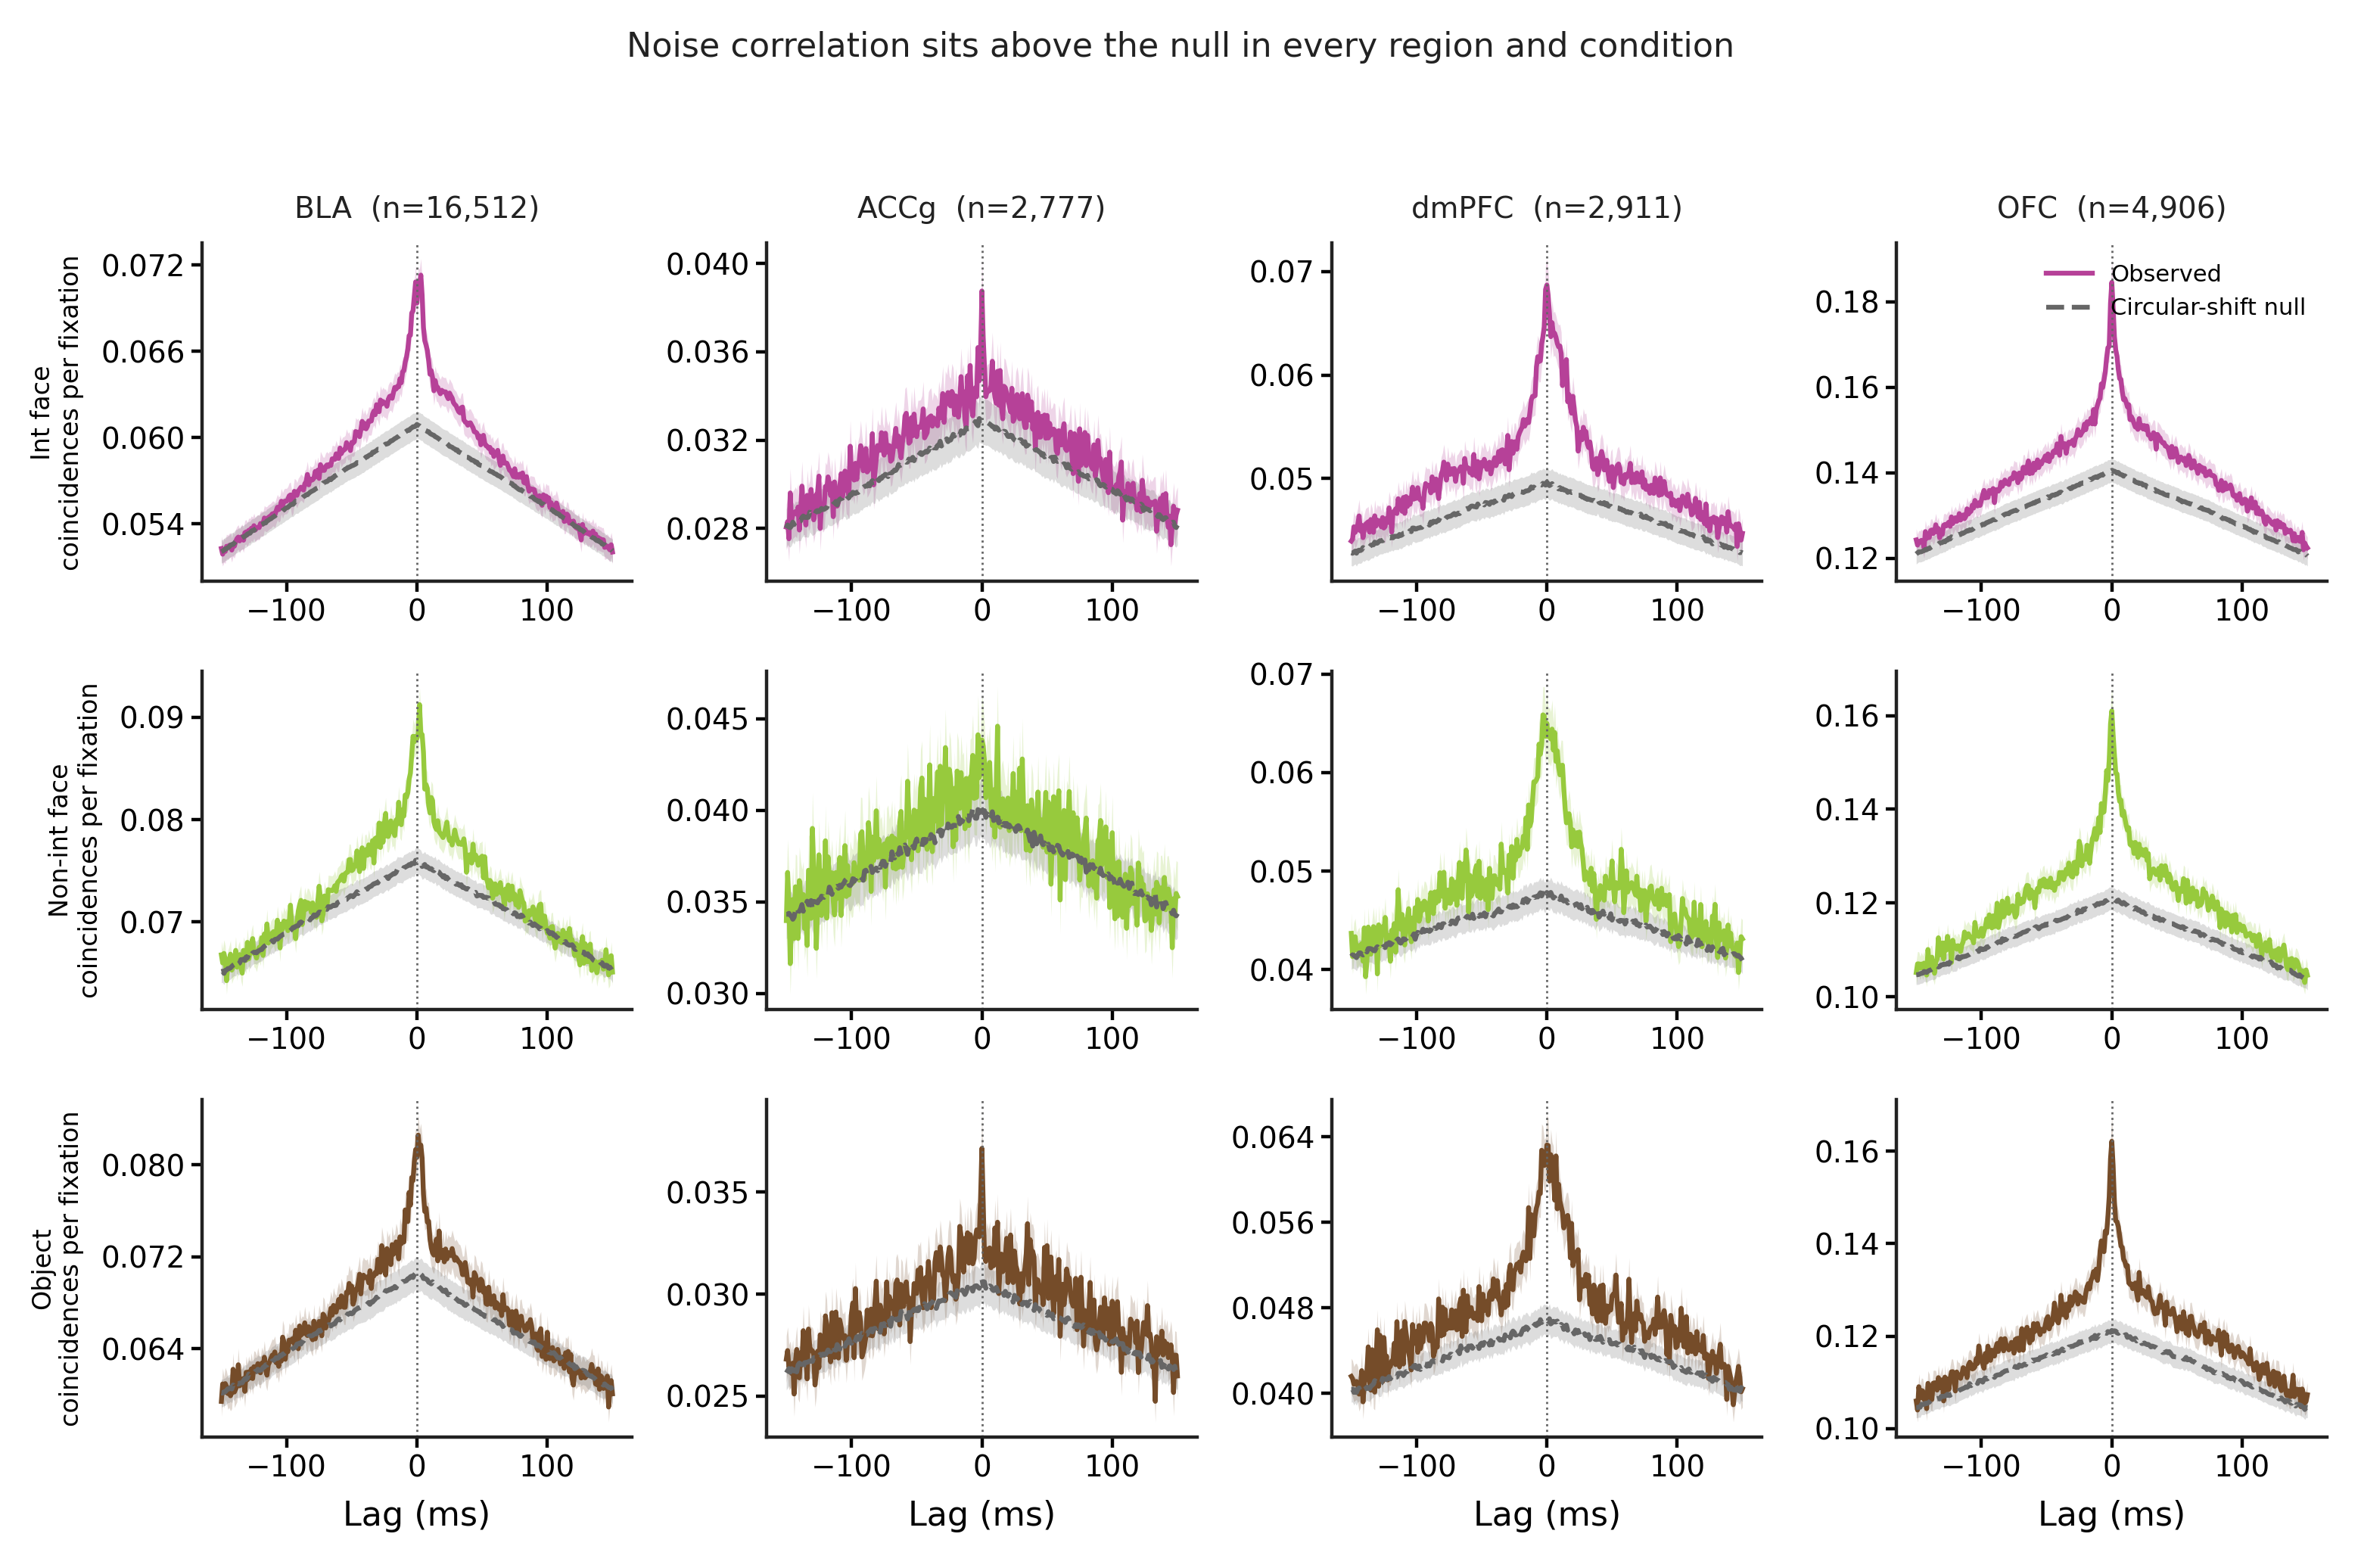

In [6]:
fig, paths = viz.plot_noise_above_null(noise_traces, figs)
display(Image(filename=str(paths["png"])))

The same quantity null-corrected, for all three conditions, trial-count matched.
Read the **effect sizes**: with thousands of pairs per region almost any
difference reaches significance.

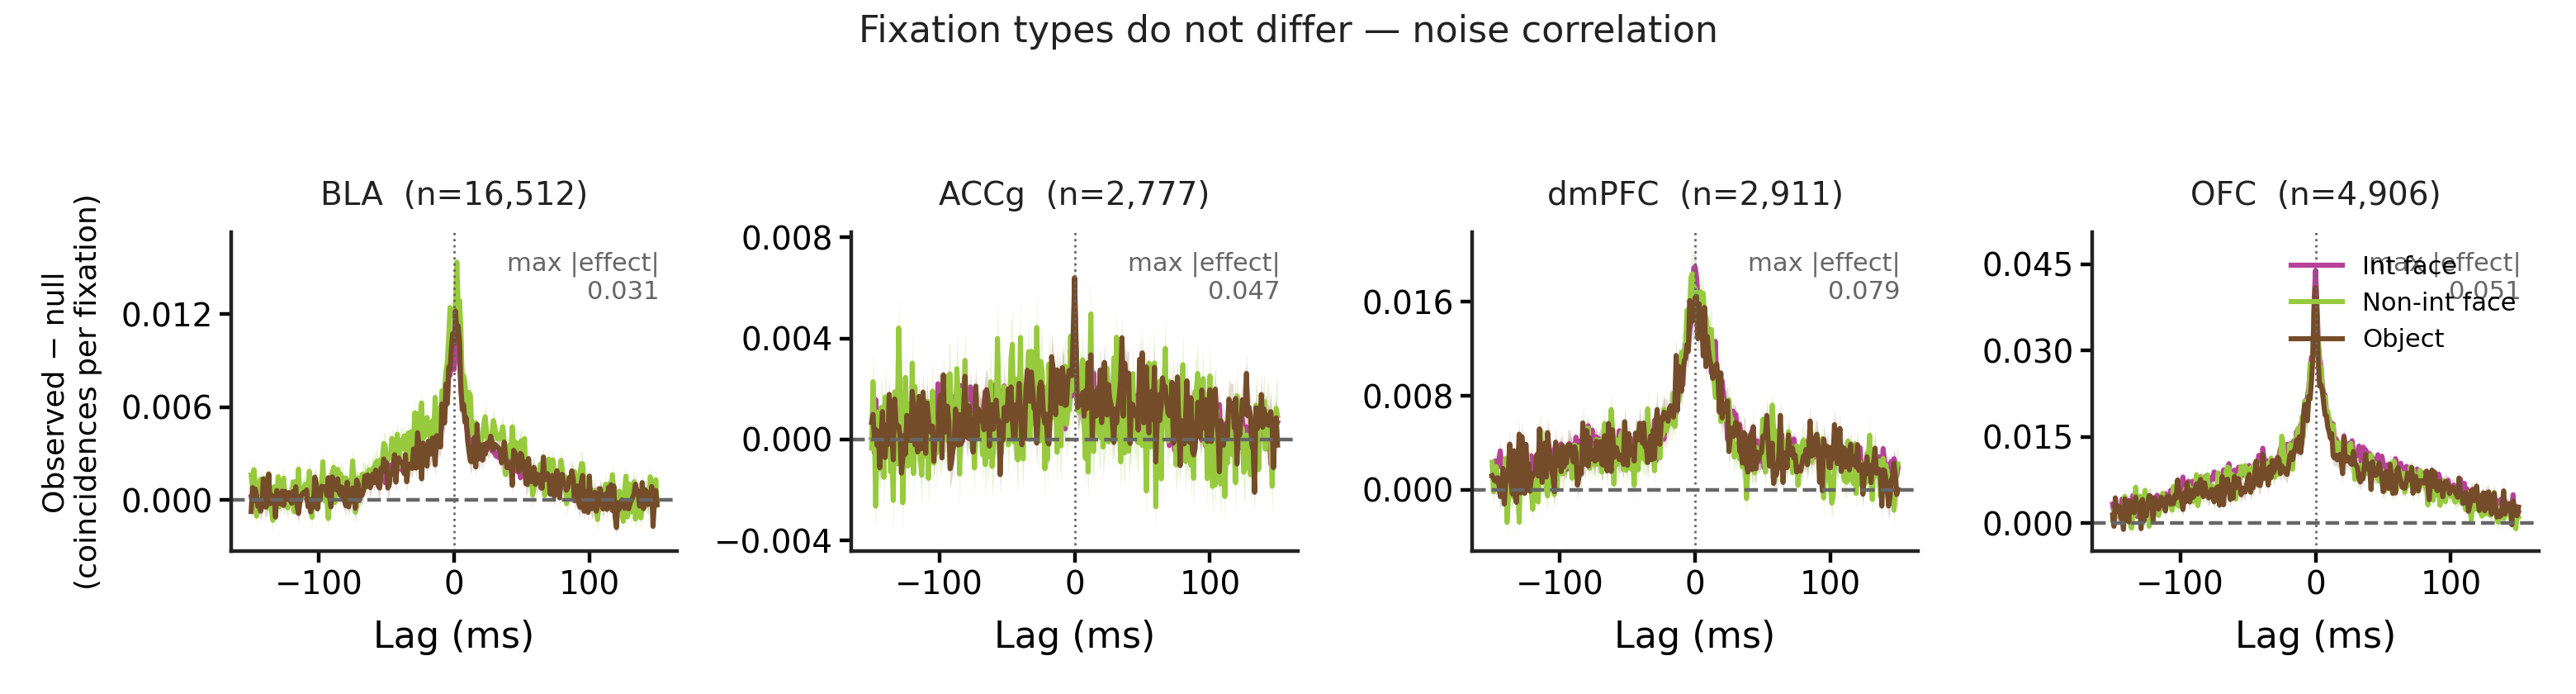

,region_pair,condition_a,condition_b,n_pairs,mean_difference,effect_size_rank_biserial,p_value_corrected,significant
0,accg,face_interactive,face_non_interactive,1796,0.00250,0.04677,0.03282,True
1,accg,face_interactive,object,1990,-0.00230,-0.00654,0.92649,False
2,accg,face_non_interactive,object,1723,-0.00516,-0.04701,0.00754,True
3,bla,face_interactive,face_non_interactive,9391,0.00213,0.03047,0.00127,True
4,bla,face_interactive,object,10012,0.00074,-0.00090,0.03559,True
5,bla,face_non_interactive,object,8479,-0.00157,-0.03067,0.20992,False
6,dmpfc,face_interactive,face_non_interactive,1906,0.00525,0.06723,0.00047,True
7,dmpfc,face_interactive,object,1813,0.00845,0.07896,0.00005,True
8,dmpfc,face_non_interactive,object,1609,0.00237,-0.01619,0.82461,False
9,ofc,face_interactive,face_non_interactive,4288,0.00585,0.05084,0.00269,True


largest |effect size| across all contrasts: 0.079
contrasts reaching significance: 8 of 12


In [7]:
noise_contrasts = psc.compare_conditions(
    noise, metric="circular_shift_peak_pm2ms_matched", group_columns=("region_pair",)
)
fig, paths = viz.plot_excess_by_condition(
    noise_traces, figs, contrasts=noise_contrasts,
    ylabel="Observed − null\n(coincidences per fixation)",
    title="Fixation types do not differ — noise correlation",
    stem="fig03_noise_excess",
)
display(Image(filename=str(paths["png"])))

display(
    noise_contrasts.loc[
        :, ["region_pair", "condition_a", "condition_b", "n_pairs",
            "mean_difference", "effect_size_rank_biserial", "p_value_corrected", "significant"]
    ].round(5)
)
print(f"largest |effect size| across all contrasts: "
      f"{noise_contrasts['effect_size_rank_biserial'].abs().max():.3f}")
print(f"contrasts reaching significance: {int(noise_contrasts['significant'].sum())} "
      f"of {len(noise_contrasts)}")

# Putting them together

## 5. Do the two measures track each other?

Spearman correlation between each pair's signal and noise correlation, per
region and fixation condition. A positive value means pairs whose mean responses
resemble each other also tend to co-fire trial to trial — which is not
guaranteed, since the two are computed by different operations on the same
trains and either can exist without the other. Stars mark ρ significantly
different from zero.

/gpfs/milgram/pi/chang/pg496/repositories/dal_monte_2022_analysis/src/dal_monte_2022_analysis/ephys/analysis/fixation_signal_correlation.py:687: PerformanceWarning: indexing past lexsort depth may impact performance.
  if key not in lookup.index:
/gpfs/milgram/pi/chang/pg496/repositories/dal_monte_2022_analysis/src/dal_monte_2022_analysis/ephys/analysis/fixation_signal_correlation.py:689: PerformanceWarning: indexing past lexsort depth may impact performance.
  value = lookup.loc[key]


pairs with both measurements: 2,849 per condition


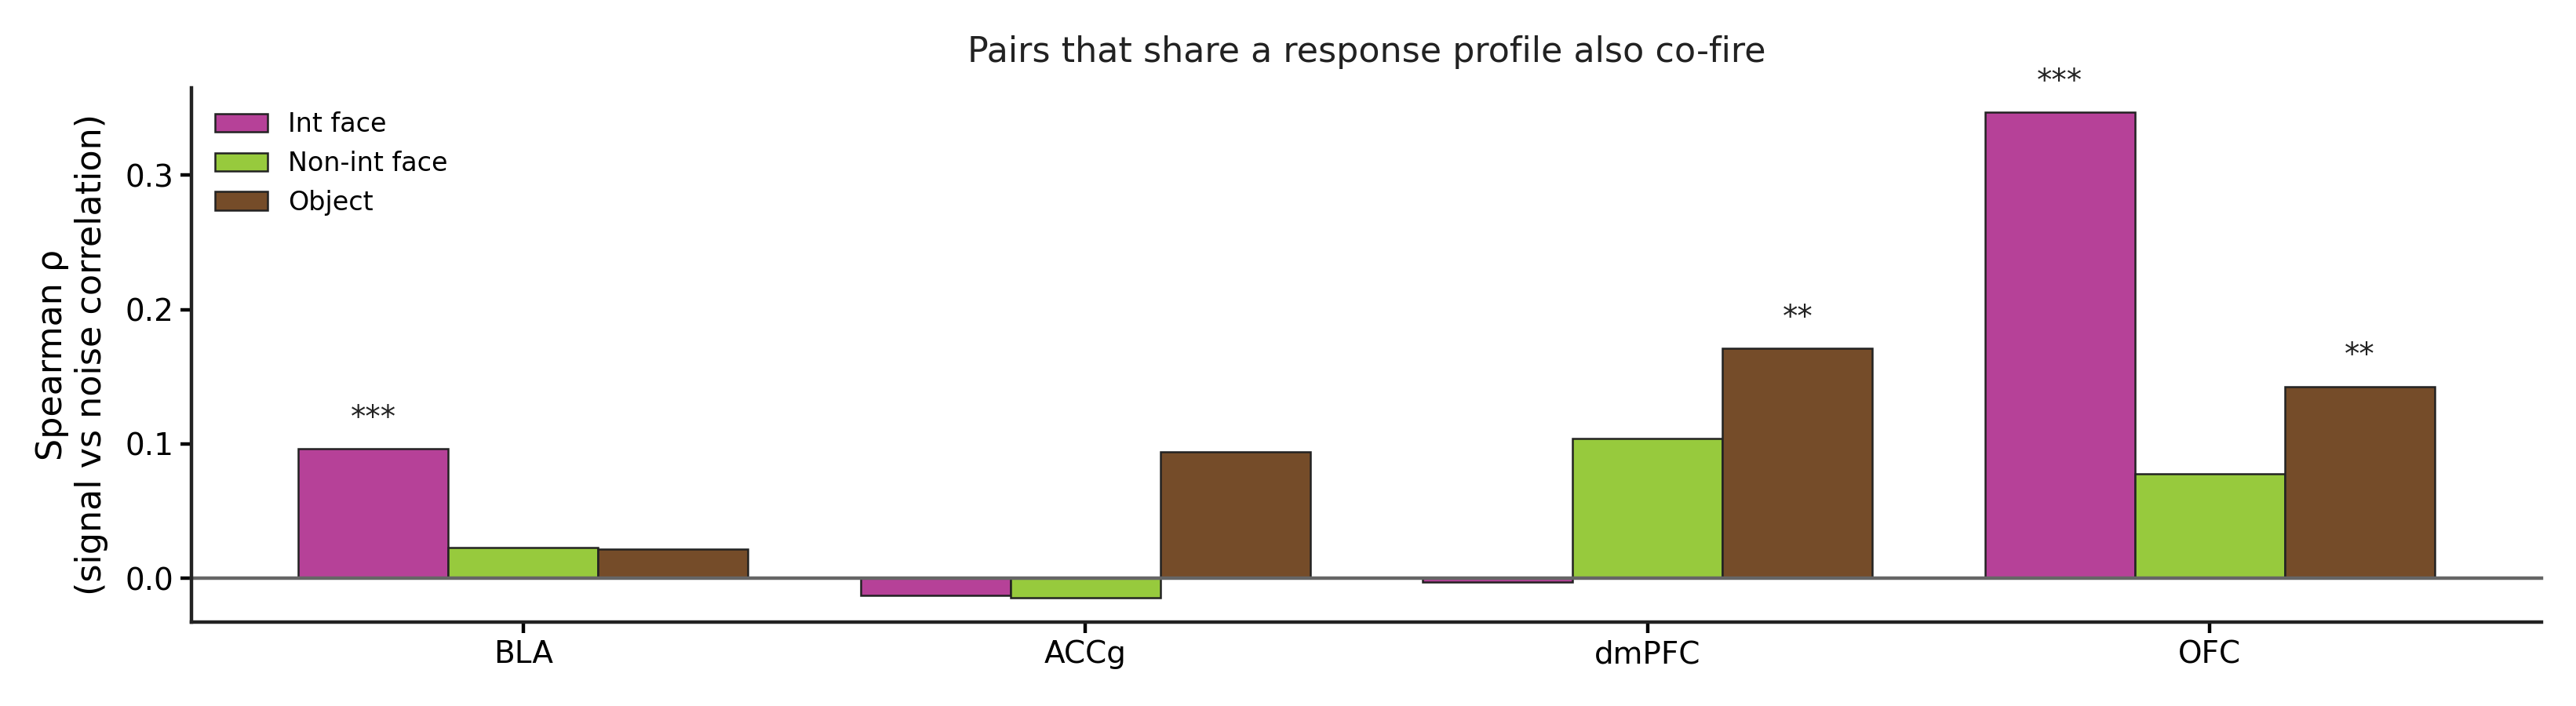

,region_pair,condition,n_pairs,spearman_rho,p_value
0,accg,face_interactive,354,-0.0128,0.8107
1,accg,face_non_interactive,325,-0.0143,0.7979
2,accg,object,351,0.0941,0.0782
3,bla,face_interactive,1714,0.0962,0.0001
4,bla,face_non_interactive,1656,0.0227,0.3557
5,bla,object,1617,0.0218,0.3800
6,dmpfc,face_interactive,320,-0.0029,0.9587
7,dmpfc,face_non_interactive,318,0.1043,0.0632
8,dmpfc,object,314,0.1709,0.0024
9,ofc,face_interactive,527,0.3467,0.0000


In [8]:
joined = sc.join_with_noise_correlation(
    signal, signal_settings, signal_metric=sc.WINDOW_METRIC
)
joined = joined.loc[joined["scope"] == "within_region"]
correlations = sc.correlate_signal_with_noise(joined)
print(f"pairs with both measurements: {len(joined) // 3:,} per condition")

fig, paths = viz.plot_signal_noise_correlation_bars(correlations, figs)
display(Image(filename=str(paths["png"])))

display(
    correlations.loc[
        :, ["region_pair", "condition", "n_pairs", "spearman_rho", "p_value"]
    ].round(4)
)

## What the two analyses say together

1. **Signal correlation is above its cross-session null**, and it varies by
   region and by fixation type — interactive face is highest where the effect
   is clearest.
2. **Noise correlation is clearly above its circular-shift null in every
   region**, so simultaneously recorded selective pairs do co-fire beyond what
   their individual rate profiles predict.
3. **Fixation type does not modulate noise correlation.** Effect sizes across
   every region and contrast are a few hundredths.
4. **The two are positively related within region** — pairs whose mean responses
   resemble each other also tend to co-fire trial to trial.

So the fixation-condition effect lives in **shared tuning**, not in
trial-by-trial coupling: what changes with interactive face is how much two
neurons' average responses resemble each other, not how tightly they co-fire on
any given fixation.

One caveat to carry: interactive-face fixations outnumber the others roughly six
to one. The noise-correlation comparisons are trial-count matched and do not
carry that; the signal-correlation comparisons cannot be, so their absolute
sizes are upper bounds even though the region and condition ordering is not
obviously driven by it.